In [152]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [153]:
df=pd.read_csv("C:\\Users\\Hp\\OneDrive\\Documents\\IEEE\\Task 4\\Zara_sales_EDA.csv",sep=";")
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


In [154]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20252 non-null  int64  
 1   Product Position  20252 non-null  str    
 2   Promotion         20252 non-null  str    
 3   Product Category  20252 non-null  str    
 4   Seasonal          20252 non-null  str    
 5   Sales Volume      20252 non-null  int64  
 6   brand             20252 non-null  str    
 7   url               20252 non-null  str    
 8   name              20251 non-null  str    
 9   description       20250 non-null  str    
 10  price             20252 non-null  float64
 11  currency          20252 non-null  str    
 12  terms             20252 non-null  str    
 13  section           20252 non-null  str    
 14  season            20252 non-null  str    
 15  material          20252 non-null  str    
 16  origin            20252 non-null  str    
dtypes: f

In [155]:
df.isnull().sum()

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
name                1
description         2
price               0
currency            0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

In [156]:
df = df.drop(columns=["Product Category", "brand", "description", "url", "currency"])
df.head()

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,name,price,terms,section,season,material,origin
0,185102,Aisle,Yes,Yes,1243,BASIC PUFFER JACKET,78.99,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,No,1429,TUXEDO JACKET,14.99,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,Yes,1168,SLIM FIT SUIT JACKET,71.95,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,No,1348,STRETCH SUIT JACKET,30.99,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,Yes,1602,DOUBLE FACED JACKET,22.99,jackets,WOMAN,Winter,Wool Blend,China


In [157]:
df['name'] = df['name'].fillna('nan')
df.isnull().sum()

Product ID          0
Product Position    0
Promotion           0
Seasonal            0
Sales Volume        0
name                0
price               0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

In [158]:
df.describe()

,Product ID,Sales Volume,price
count,20252.000000,20252.000000,20252.000000
mean,208931.432303,1097.400454,41.949061
std,8961.076507,298.234609,23.380960
min,110075.000000,518.000000,12.000000
25%,204442.750000,849.000000,23.950000
50%,209505.500000,990.000000,35.950000
75%,214568.250000,1364.250000,53.950000
max,219631.000000,1940.000000,134.990000


In [159]:
import pycountry_convert as pc

def country_to_continent(country_name):
    try:
        country_code = pc.country_name_to_country_alpha2(country_name, cn_name_format="default")
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        return continent_name
    except:
        return "Unknown"

df['continent'] = df['origin'].apply(country_to_continent)
df.head()

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,name,price,terms,section,season,material,origin,continent
0,185102,Aisle,Yes,Yes,1243,BASIC PUFFER JACKET,78.99,jackets,MAN,Winter,Polyester,Brazil,South America
1,188771,Aisle,Yes,No,1429,TUXEDO JACKET,14.99,jackets,MAN,Autumn,Cotton,Turkey,Asia
2,180176,End-cap,Yes,Yes,1168,SLIM FIT SUIT JACKET,71.95,jackets,WOMAN,Autumn,Polyester,Morocco,Africa
3,112917,Aisle,Yes,No,1348,STRETCH SUIT JACKET,30.99,jackets,MAN,Spring,Polyester,China,Asia
4,192936,End-cap,Yes,Yes,1602,DOUBLE FACED JACKET,22.99,jackets,WOMAN,Winter,Wool Blend,China,Asia


In [160]:
df['revenue'] = df['Sales Volume'] * df['price']
df.head()

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,name,price,terms,section,season,material,origin,continent,revenue
0,185102,Aisle,Yes,Yes,1243,BASIC PUFFER JACKET,78.99,jackets,MAN,Winter,Polyester,Brazil,South America,98184.57
1,188771,Aisle,Yes,No,1429,TUXEDO JACKET,14.99,jackets,MAN,Autumn,Cotton,Turkey,Asia,21420.71
2,180176,End-cap,Yes,Yes,1168,SLIM FIT SUIT JACKET,71.95,jackets,WOMAN,Autumn,Polyester,Morocco,Africa,84037.60
3,112917,Aisle,Yes,No,1348,STRETCH SUIT JACKET,30.99,jackets,MAN,Spring,Polyester,China,Asia,41774.52
4,192936,End-cap,Yes,Yes,1602,DOUBLE FACED JACKET,22.99,jackets,WOMAN,Winter,Wool Blend,China,Asia,36829.98


In [161]:
top_10_revenue = df.sort_values("Sales Volume", ascending=False).head(5)
top_10_revenue[["Product ID", "name", "Sales Volume","revenue", "season", "material", "origin"]]

,Product ID,name,Sales Volume,revenue,season,material,origin
5100,204480,TAILORED COLORBLOCK KNIT CROP SWEATER NAVY,1940,36840.60,Summer,Cotton,Portugal
8106,207486,SLIM BOXY FIT DENIM JACKET,1940,44523.00,Winter,Polyester,Bangladesh
4581,203961,KNIT DOUBLE FACED JACKET ECRU,1929,38560.71,Winter,Wool,Portugal
15174,214554,RELAXED ZIPPERED JACKET IVORY,1926,42372.00,Summer,Linen,Spain
9982,209362,RIBBED 100% WOOL SUIT JACKET GREY,1917,40257.00,Winter,Wool Blend,Turkey


In [162]:
pd.crosstab(df["season"], df["material"], margins=True).style.background_gradient(cmap="Blues")

material,Acrylic,Cotton,Denim,Linen,Linen Blend,Polyester,Satin,Silk,Viscose,Wool,Wool Blend,All
season,,,,,,,,,,,,
Autumn,429,1098,557,0,0,1493,70,15,516,1825,1662,7665
Spring,5,1468,292,1338,418,516,36,11,259,38,156,4537
Summer,15,954,28,1235,389,102,8,5,48,60,62,2906
Winter,432,331,150,0,0,664,18,7,167,1882,1493,5144
All,881,3851,1027,2573,807,2775,132,38,990,3805,3373,20252


Cross table shows Wool and Cotton dominate in Autumn/Winter, while Linen and Denim peak in Spring/Summer. Clear seasonal-material pattern.

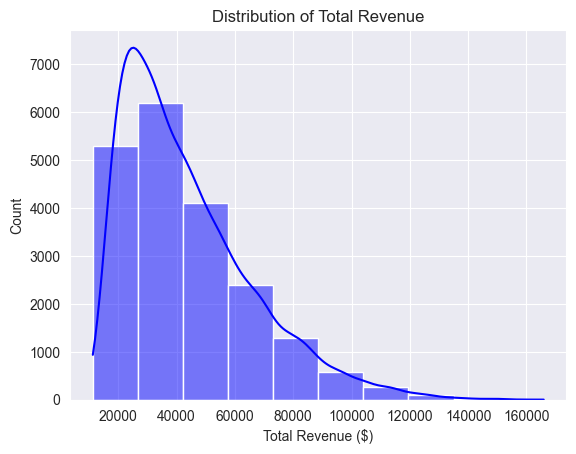

In [163]:
sns.histplot(
    data=df,
    x="revenue",
    bins=10,       
    kde=True,    
    color="blue"
)

plt.title("Distribution of Total Revenue")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Count")
plt.show()

Histogram Keep most products generate low-to-mid revenue ($20k–$40k), with very few reaching high revenue. The distribution is right-skewed, meaning a small number of products are top earners.

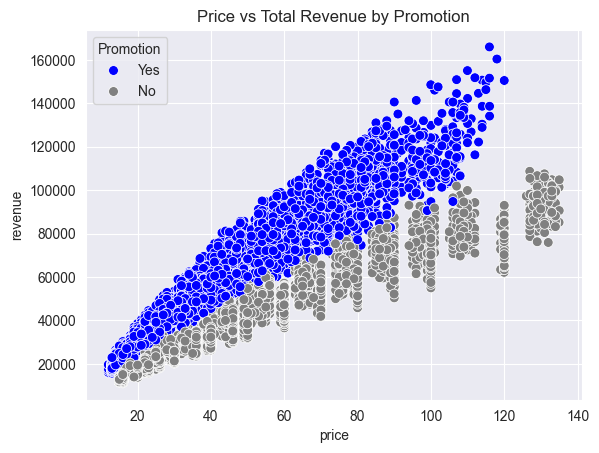

In [164]:
sns.set_style("darkgrid") 

sns.scatterplot(
    data=df,
    x="price",
    y="revenue",
    hue="Promotion",   
    s=50,
    palette={"Yes": "blue", "No": "gray"}       
)

plt.title("Price vs Total Revenue by Promotion")
plt.show()

The scatter plot shows a strong positive relationship between price and total revenue.In Addition, products under promotion consistently generate higher revenue compared to non-promoted products at similar price levels, indicating the effectiveness of promotional strategies.

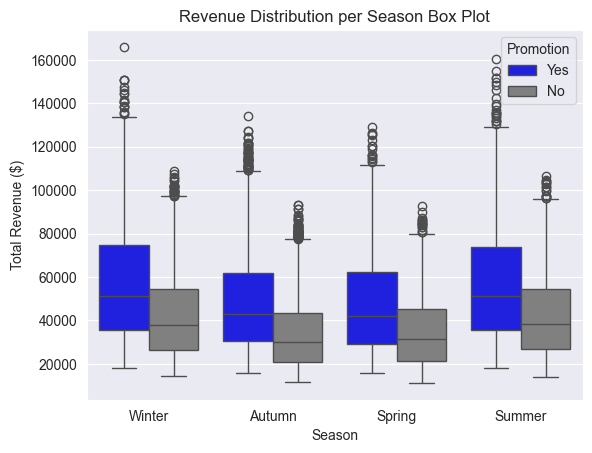

In [165]:
sns.boxplot(
    data=df,
    x="season",
    y="revenue",
    hue="Promotion",
    palette={"Yes": "blue", "No": "gray"}
)

plt.title("Revenue Distribution per Season Box Plot")
plt.xlabel("Season")
plt.ylabel("Total Revenue ($)")
plt.show()

The box plot shows that promotional activities significantly increase revenue across all seasons. While revenue is generally higher in Summer and Winter, promotions consistently shift the revenue distribution upward. Additionally, promotional periods exhibit greater variability and more high-value outliers, indicating occasional exceptional sales performance.

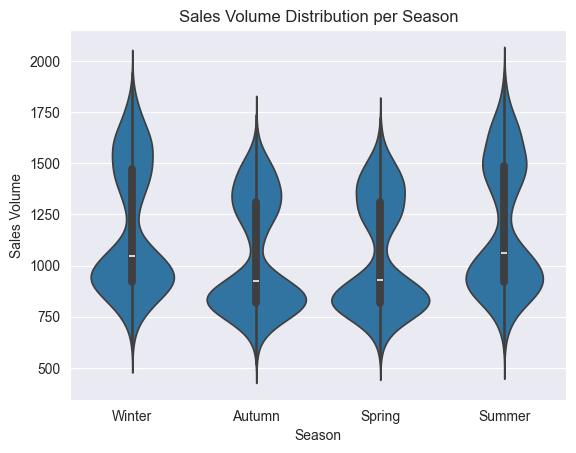

In [166]:
sns.violinplot(
    data=df,
    x="season",
    y="Sales Volume",
)

plt.title("Sales Volume Distribution per Season")
plt.xlabel("Season")
plt.ylabel("Sales Volume")
plt.show()

All seasons have a similar sales volume distribution (~750–1500 units). Winter has the widest spread, reaching up to 2000 units, meaning it has the most variation in sales. Autumn has the most concentrated distribution around ~900 units, indicating more consistent but moderate sales.

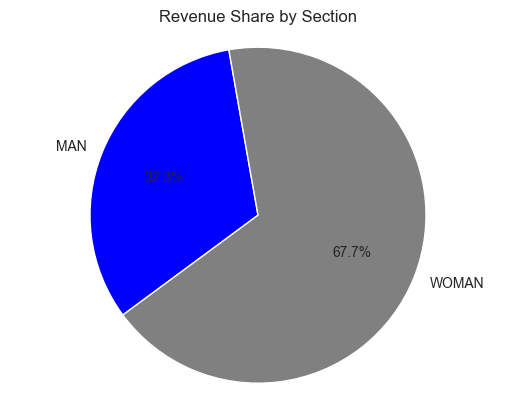

In [167]:
revenue_by_section = df.groupby("section")["revenue"].sum()
colors = ["blue", "gray"]
plt.pie(
    revenue_by_section,
    labels=revenue_by_section.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=100
)
plt.title("Revenue Share by Section")
plt.axis("equal")
plt.show()

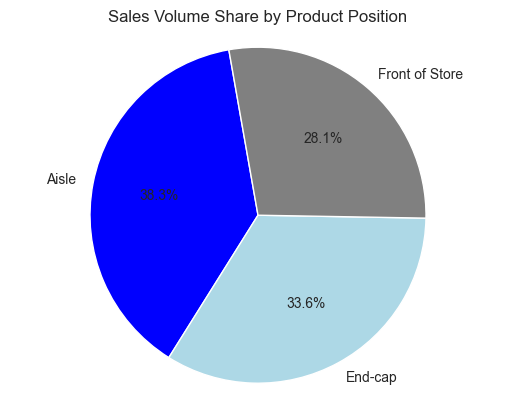

In [168]:
sales_volume_by_section = df.groupby("Product Position")["Sales Volume"].sum()
colors = ["blue","lightblue", "gray"]
plt.pie(
    sales_volume_by_section,
    labels=sales_volume_by_section.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=100
)
plt.title("Sales Volume Share by Product Position")
plt.axis("equal")
plt.show()

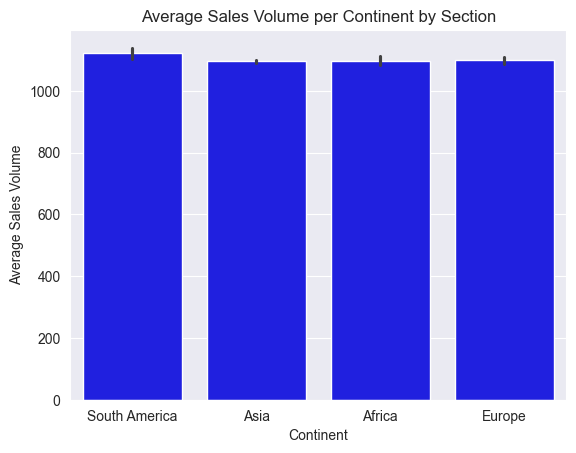

In [171]:
sns.barplot(
    data=df,
    x="continent",
    y="Sales Volume",
    color="blue"  
)

plt.title("Average Sales Volume per Continent by Section")
plt.xlabel("Continent")
plt.ylabel("Average Sales Volume")
plt.show()

Asia dominates in average sales volume, reflecting Zara's heavy manufacturing presence there.
Europe and Africa follow, while South America contributes the least indicating that
continent of origin may correlate with production scale and product availability.

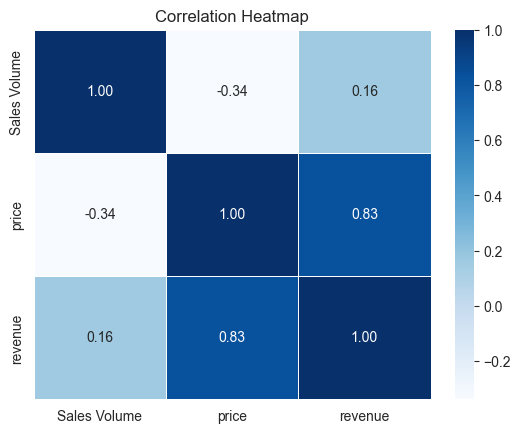

In [170]:
coloumns = df[['Sales Volume', 'price', 'revenue']].corr()

sns.heatmap(
    coloumns,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Revenue shows a strong positive correlation with both price and Sales Volume, 
which is expected since revenue = price × sales volume. 
Price and Sales Volume have a weak/negative correlation, suggesting 
that higher-priced items do not necessarily sell in higher quantities.

Summary

This EDA analyzed 20,252 Zara jacket products across multiple dimensions.

Findings:
Promotion works promoted products consistently achieve higher sales volume and revenue than non-promoted ones.
Seasonality matters Wool and Cotton dominate Autumn/Winter, while Linen and Denim peak in Spring/Summer.
Revenue is right-skewed most products generate $20k–$40k, with only a few top earners exceeding $100k.
Women's section leads WOMAN section generates a higher revenue share than MAN.
Aisle placement drives sales products placed in aisles have the highest sales volume share.
Asia dominates production the majority of products originate from Asian countries.
Price vs Sales Volume higher-priced items do not necessarily sell more units; promotion compensates for price sensitivity.
Winter has the highest variation in sales volume, while Autumn is the most consistent season.

Conclusion:
Zara's sales performance is heavily influenced by promotional strategy, seasonal material choices, product placement, and pricing. 
To maximize revenue, focus should be placed on promoting mid-range priced products, 
optimizing aisle placements, and aligning material sourcing with seasonal demand.